<a href="https://colab.research.google.com/github/omar192501/gym_subscribe_prediction/blob/main/gym_subscribe_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
df= pd.DataFrame({
    "age": [22,35,28,40,31,27,45,33,29,38,24,36,30,41,26],
    "income_rm": [2500,4500,3000,5000,3200,2800,5200,3400,3100,4700,2600,4400,3300,5100,2900],
    "distance_km": [2,5,7,3,8,4,6,9,5,4,10,3,7,2,6],
    "trial_visits": [3,4,2,5,1,3,4,2,3,4,1,5,2,4,2],
    "subscribe": [1,1,0,1,0,1,1,0,1,1,0,1,0,1,0]
})
display(df)

,age,income_rm,distance_km,trial_visits,subscribe
0,22,2500,2,3,1
1,35,4500,5,4,1
2,28,3000,7,2,0
3,40,5000,3,5,1
4,31,3200,8,1,0
5,27,2800,4,3,1
6,45,5200,6,4,1
7,33,3400,9,2,0
8,29,3100,5,3,1
9,38,4700,4,4,1


In [3]:
x=df.drop("subscribe", axis=1)
y=df["subscribe"]
display(x,y)

,age,income_rm,distance_km,trial_visits
0,22,2500,2,3
1,35,4500,5,4
2,28,3000,7,2
3,40,5000,3,5
4,31,3200,8,1
5,27,2800,4,3
6,45,5200,6,4
7,33,3400,9,2
8,29,3100,5,3
9,38,4700,4,4


,subscribe
0,1
1,1
2,0
3,1
4,0
5,1
6,1
7,0
8,1
9,1


In [4]:
x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
display(x_test,x_train,y_test,y_train)

,age,income_rm,distance_km,trial_visits
3,40,5000,3,5
8,29,3100,5,3
2,28,3000,7,2
13,41,5100,2,4
11,36,4400,3,5
7,33,3400,9,2
4,31,3200,8,1
12,30,3300,7,2
5,27,2800,4,3
14,26,2900,6,2


,age,income_rm,distance_km,trial_visits
10,24,2600,10,1
6,45,5200,6,4
9,38,4700,4,4


,subscribe
3,1
8,1
2,0
13,1
11,1
7,0
4,0
12,0
5,1
14,0


,subscribe
10,0
6,1
9,1


In [5]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [6]:
y_pred=model.predict(x_test)
display(y_pred)

array([1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1])

In [7]:
acc=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
print("accuracy_score:",acc)
print("confusion_matrix:",cm)
print("classification_report:",report)

accuracy_score: 0.9166666666666666
confusion_matrix: [[4 1]
 [0 7]]
classification_report:               precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.88      1.00      0.93         7

    accuracy                           0.92        12
   macro avg       0.94      0.90      0.91        12
weighted avg       0.93      0.92      0.91        12



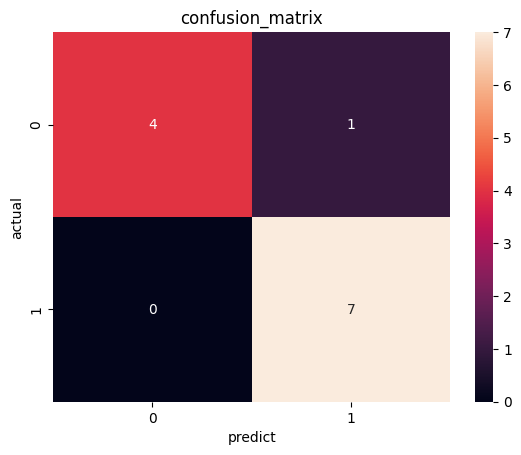

In [8]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,annot=True,fmt="d")
plt.xlabel("predict")
plt.ylabel("actual")
plt.title("confusion_matrix")
plt.show()

In [9]:
new_customer = pd.DataFrame([[30, 3900, 4, 4]],columns=["age", "income_rm", "distance_km", "trial_visits"])
new_customer_scaled = scaler.transform(new_customer)
prediction = model.predict(new_customer_scaled)
print(prediction)

[1]
